# Chapter 10: Classification of Simple Lie Algebras and Symmetric Spaces

**Source Span.** `Differential Geometry, Lie Groups, and Symmetric Spaces.pdf`, Chapter X, printed pages `438-458` (approximately PDF pages `465-485`).

This notebook is a standalone visual guide to the opening move of Helgason's classification chapter. The printed span does three things: it reduces the geometric classification problem to algebraic data, lists the classical matrix groups and their Cartan involution families, and begins the abstract root-system machine that later becomes the Dynkin-diagram classification.

The goal here is not to reproduce the book's list. It is to make the classification pipeline inspectable:

- a symmetric space is represented by an orthogonal symmetric Lie algebra `(l, s)`;
- type II spaces are compact simple groups with bi-invariant metrics;
- type I spaces reduce to compact simple algebras, involutions, centers, and equivalent real-form problems;
- the classical families are organized by fixed algebra, noncompact real form, rank, and Hermitian behavior;
- root systems, Weyl chambers, root strings, and Dynkin diagrams encode the finite combinatorics that makes the later classification possible;
- the chapter introduction announces finite-order automorphisms later on; in this source span the concrete automorphism work is the order-two case needed for symmetric spaces.


## Visual Storyboard and Library Routing

**Chapter goal.** Learn how the first part of Chapter X turns a geometric classification problem into algebraic and combinatorial objects that can be checked directly.

**Source span read.** Course `AGENTS.md`, `source_map.json`, and printed pages `438-458`: Lemma 1.1, Proposition 1.2, Lemma 1.3, Proposition 1.4, Proposition 1.5, the classical matrix-group definitions and connectivity lemmas, the classical Cartan involution families `AI`, `AII`, `AIII`, `BDI`, `DIII`, `CI`, `CII`, and the root-system definitions through irreducible decomposition.

**Concept inventory.** Isometry classes of irreducible globally symmetric spaces; orthogonal symmetric Lie algebras; compact/noncompact duality; type II diagonal quotient model; type I problems `A`, `B`, `C` and equivalent `A'`, `B'`, `B''`; real simple Lie algebras as complex algebras viewed real or real forms; classical groups preserving Hermitian, quadratic, and symplectic forms; Cartan involution eigenspace splits; finite-order automorphisms as a downstream chapter goal, with involutions treated in this span; rank; Hermitian symmetric spaces; root-system reflections; Cartan integers; reduced and nonreduced systems; Weyl groups; root strings; simple bases, Weyl chambers, and irreducible components.

**Library routing table.**

| Concept | Representation | Library | Why this route | Fallback |
| --- | --- | --- | --- | --- |
| Classification reduction | Directed proof graph | NetworkX + Matplotlib | The chapter is a dependency pipeline, so a graph exposes which algebraic object solves which geometric task. | Markdown table |
| Type II quotient | Finite diagonal-quotient model | NumPy + Matplotlib | A small finite group tests the quotient mechanics without pretending to approximate compact geometry. | Static commutative diagram |
| Classical Cartan families | CSV table + rank/dimension plot | Python data + Matplotlib | The formulas become inspectable invariants instead of an opaque list. | Markdown table only |
| AIII involution | Matrix heatmaps + bracket tests | NumPy | A concrete `su(3)` block split checks the symmetric-pair bracket relations. | SymPy exact matrices |
| Root systems and Weyl chambers | Root arrows, reflection hyperplanes, interactive HTML | Matplotlib + Plotly | The reflection/chamber geometry is spatial and benefits from both durable PNG and hoverable HTML. | Matplotlib PNG only |
| Reduced vs nonreduced roots and root strings | Exact rank-two finite models | fractions + Matplotlib | The printed span distinguishes ordinary roots from restricted roots; `BC2` makes the distinction visible. | Handwritten coordinate table |
| Dynkin encoding | Small graph diagrams with Cartan matrices | NetworkX + Matplotlib | Dynkin diagrams are compressed Cartan-integer data, not decorative graph pictures. | CSV matrix table |

**Visual sequence.** Reduction graph; type II diagonal quotient grid; classical family rank ladder; AIII block split; A2 Weyl chamber with HTML companion; BC2/nonreduced root-string diagram; rank-two Dynkin encoding; parameter-sweep lab.

**Computational checks.** Graph acyclicity and named source claims; quotient invariance under diagonal action; dimension/rank formulas; AIII bracket containment `[k,k] in k`, `[k,p] in p`, `[p,p] in k`; reflection invariance and integral Cartan entries; root-string continuity and `p - q` equality; reduced subsystem checks; Dynkin matrix validity; artifact existence and nonzero size recorded in `checks/final_sanity.json`.


In [1]:
from pathlib import Path
from fractions import Fraction
import itertools
import json
import math
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import networkx as nx
import numpy as np
import sympy as sp

try:
    import plotly.graph_objects as go
except Exception:
    go = None

COURSE_FOLDER = "Differential-Geometry-Lie-Groups-and-Symmetric-Spaces"
UNIT_KEY = "chapter-10-classification-of-simple-lie-algebras-and-symmetric"
UNIT_TITLE = "Classification of Simple Lie Algebras and Symmetric Spaces"


def locate_book_root() -> Path:
    starts = [Path.cwd(), *Path.cwd().parents]
    candidates = []
    for start in starts:
        candidates.append(start)
        candidates.append(start / COURSE_FOLDER)
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate the Helgason course root")


BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
HTML = ARTIFACT_ROOT / "html"

GENERATED_ARTIFACTS = []
CHECK_RESULTS = {}


def track(path):
    path = Path(path)
    GENERATED_ARTIFACTS.append(path)
    return path


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def show(path, width=760, height=520):
    display_artifact(Path(path), width=width, height=height)
    print(rel(path))


plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

warnings.filterwarnings("ignore", message="Consider using IPython.display.IFrame instead")
print(f"Book root: {BOOK_ROOT.name}")
print(f"Artifact root: {rel(ARTIFACT_ROOT)}")


Book root: Differential-Geometry-Lie-Groups-and-Symmetric-Spaces
Artifact root: artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric


## 1. The Classification Reduction as a Dependency Graph

The opening pages make a precise reduction. Instead of trying to list all irreducible globally symmetric spaces directly, the problem is transferred to orthogonal symmetric Lie algebras. Duality lets the noncompact side ride on the compact side, type II collapses to compact simple groups with bi-invariant metrics, and type I becomes three algebraic questions: compact simple algebras, involutions up to conjugacy, and centers.

The graph below is a reading map: every arrow is a mathematical dependency used by the source span. If a later classification entry looks mysterious, trace it backward until you find whether it came from a real form, an involution, a root system, or a center.


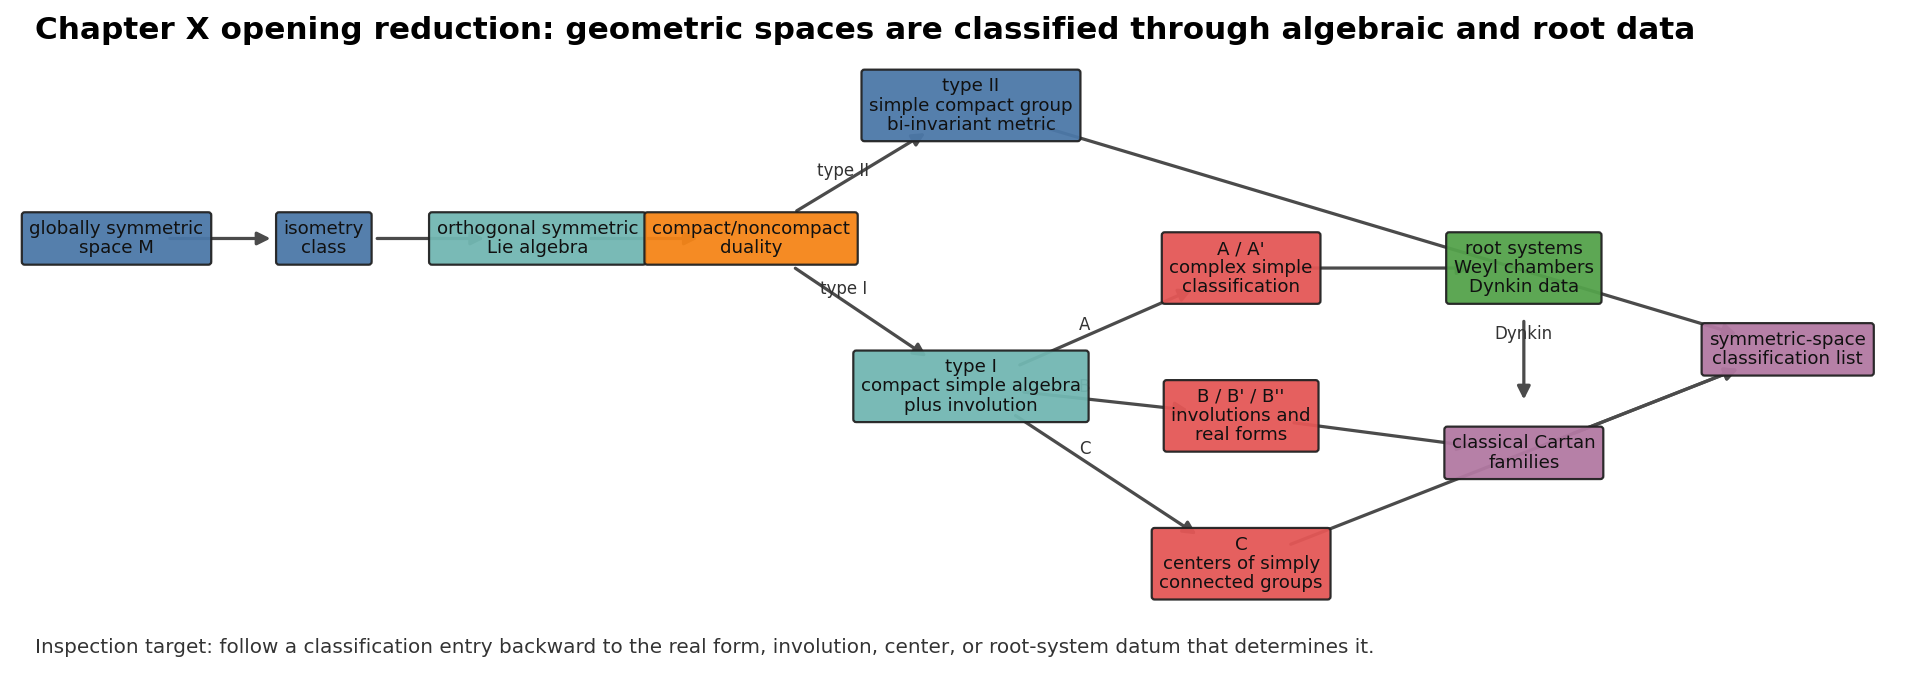

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/figures/classification-reduction-map.png


In [2]:
reduction_nodes = {
    "space": ("globally symmetric\nspace M", "geometry"),
    "isometry": ("isometry\nclass", "geometry"),
    "symalg": ("orthogonal symmetric\nLie algebra", "algebra"),
    "duality": ("compact/noncompact\nduality", "bridge"),
    "typeII": ("type II\nsimple compact group\nbi-invariant metric", "geometry"),
    "typeI": ("type I\ncompact simple algebra\nplus involution", "algebra"),
    "A": ("A / A'\ncomplex simple\nclassification", "problem"),
    "B": ("B / B' / B''\ninvolutions and\nreal forms", "problem"),
    "C": ("C\ncenters of simply\nconnected groups", "problem"),
    "classical": ("classical Cartan\nfamilies", "classification"),
    "roots": ("root systems\nWeyl chambers\nDynkin data", "combinatorics"),
    "list": ("symmetric-space\nclassification list", "classification"),
}

reduction_edges = [
    ("space", "isometry", "classify"),
    ("isometry", "symalg", "Lemma 1.1"),
    ("symalg", "duality", "dual"),
    ("duality", "typeII", "type II"),
    ("duality", "typeI", "type I"),
    ("typeII", "list", "group case"),
    ("typeI", "A", "A"),
    ("typeI", "B", "B"),
    ("typeI", "C", "C"),
    ("A", "roots", "roots"),
    ("B", "classical", "involutions"),
    ("roots", "classical", "Dynkin"),
    ("C", "list", "centers"),
    ("classical", "list", "pairs"),
]

G_reduction = nx.DiGraph()
for key, (label, role) in reduction_nodes.items():
    G_reduction.add_node(key, label=label, role=role)
for src, dst, reason in reduction_edges:
    G_reduction.add_edge(src, dst, reason=reason)

pos = {
    "space": (0.8, 3.55),
    "isometry": (2.45, 3.55),
    "symalg": (4.15, 3.55),
    "duality": (5.85, 3.55),
    "typeII": (7.6, 4.45),
    "typeI": (7.6, 2.55),
    "A": (9.75, 3.35),
    "B": (9.75, 2.35),
    "C": (9.75, 1.35),
    "roots": (12.0, 3.35),
    "classical": (12.0, 2.1),
    "list": (14.1, 2.8),
}
role_colors = {
    "geometry": "#4c78a8",
    "algebra": "#72b7b2",
    "bridge": "#f58518",
    "problem": "#e45756",
    "combinatorics": "#54a24b",
    "classification": "#b279a2",
}

fig, ax = plt.subplots(figsize=(15.2, 5.4))
ax.set_xlim(0, 15.0)
ax.set_ylim(0.55, 5.05)
ax.set_axis_off()
for src, dst, reason in reduction_edges:
    x1, y1 = pos[src]
    x2, y2 = pos[dst]
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops={
            "arrowstyle": "-|>",
            "lw": 1.45,
            "color": "#4b4b4b",
            "shrinkA": 24,
            "shrinkB": 24,
            "mutation_scale": 12,
        },
    )
    if reason in {"type I", "type II", "A", "B", "C", "Dynkin"}:
        mx, my = (0.58 * x1 + 0.42 * x2, 0.58 * y1 + 0.42 * y2)
        ax.text(mx, my + 0.08, reason, ha="center", va="center", fontsize=7.5, color="#333333")

for key, (label, role) in reduction_nodes.items():
    x, y = pos[key]
    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=8.2,
        linespacing=1.08,
        color="#111111",
        bbox={
            "boxstyle": "round,pad=0.42,rounding_size=0.16",
            "facecolor": role_colors[role],
            "edgecolor": "#222222",
            "linewidth": 1.0,
            "alpha": 0.95,
        },
    )

ax.text(
    0.15,
    4.9,
    "Chapter X opening reduction: geometric spaces are classified through algebraic and root data",
    fontsize=14,
    weight="bold",
    ha="left",
)
ax.text(
    0.15,
    0.75,
    "Inspection target: follow a classification entry backward to the real form, involution, center, or root-system datum that determines it.",
    fontsize=9,
    color="#333333",
    ha="left",
)
reduction_map_path = track(save_matplotlib(fig, FIGURES / "classification-reduction-map.png"))
plt.close(fig)

reduction_json = {
    "source_span": "printed pages 438-458, PDF pages approximately 465-485",
    "nodes": {key: {"label": label, "role": role} for key, (label, role) in reduction_nodes.items()},
    "edges": [{"from": src, "to": dst, "reason": reason} for src, dst, reason in reduction_edges],
    "core_claims": [
        "isometry classes correspond to isomorphism classes of irreducible orthogonal symmetric Lie algebras",
        "noncompact irreducible spaces are recovered from compact duals",
        "type II spaces are compact connected simple groups with bi-invariant metrics",
        "type I classification reduces to compact simple algebras, involutions, and centers",
    ],
    "checks": {
        "directed_graph_is_acyclic": bool(nx.is_directed_acyclic_graph(G_reduction)),
        "contains_type_I_and_type_II": {"typeI", "typeII"}.issubset(G_reduction.nodes),
    },
}
reduction_json_path = track(save_json(reduction_json, CHECKS / "classification-reduction-map.json"))
CHECK_RESULTS["classification_reduction_graph_is_acyclic"] = reduction_json["checks"]["directed_graph_is_acyclic"]
CHECK_RESULTS["classification_reduction_has_main_types"] = reduction_json["checks"]["contains_type_I_and_type_II"]
show(reduction_map_path, width=900)


## 2. Type II: A Diagonal Quotient Model

For type II, the symmetric algebra has two isomorphic simple ideals exchanged by the involution. The corresponding model looks like `(L0 x L0)/diag(L0)`, and each coset can be represented by a single group element. The source uses this to show that the symmetric space carries a group law and that the metric is invariant under left and right translations.

The finite model below uses `S3` only as a test stand for the quotient mechanics. It is not a compact simple Lie group. The invariant to inspect is the color: all pairs `(a, b)` with the same value of `a b^{-1}` represent the same point of the diagonal quotient.


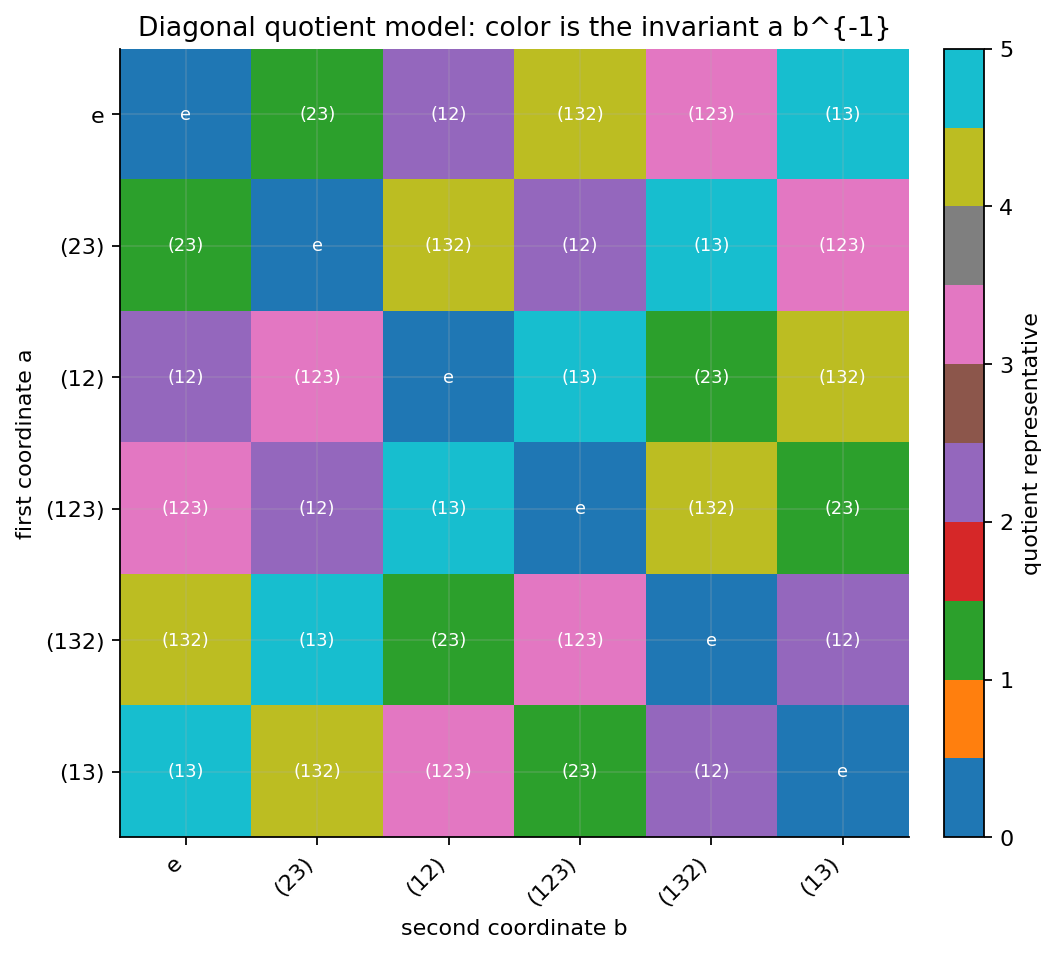

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/figures/type-ii-diagonal-quotient-model.png


In [3]:
def compose(p, q):
    return tuple(p[i] for i in q)


def inverse(p):
    inv = [0] * len(p)
    for i, value in enumerate(p):
        inv[value] = i
    return tuple(inv)


S3 = sorted(itertools.permutations(range(3)))
identity = (0, 1, 2)
names = {
    identity: "e",
    (1, 0, 2): "(12)",
    (2, 1, 0): "(13)",
    (0, 2, 1): "(23)",
    (1, 2, 0): "(123)",
    (2, 0, 1): "(132)",
}


def phi(pair):
    a, b = pair
    return compose(a, inverse(b))


def right_diagonal(pair, h):
    a, b = pair
    return (compose(a, h), compose(b, h))


pairs = list(itertools.product(S3, S3))
fibers = {g: [pair for pair in pairs if phi(pair) == g] for g in S3}
phi_invariant = all(phi(right_diagonal(pair, h)) == phi(pair) for pair in pairs for h in S3)
fiber_sizes = {names[g]: len(fibers[g]) for g in S3}
induced_product_ok = all(
    compose(phi(pair1), phi(pair2)) in S3
    for pair1 in pairs
    for pair2 in pairs
)

grid = np.array([[S3.index(phi((a, b))) for b in S3] for a in S3])
fig, ax = plt.subplots(figsize=(7.2, 6.4))
image = ax.imshow(grid, cmap="tab10", vmin=0, vmax=len(S3) - 1)
ax.set_xticks(range(len(S3)), [names[g] for g in S3], rotation=45, ha="right")
ax.set_yticks(range(len(S3)), [names[g] for g in S3])
ax.set_xlabel("second coordinate b")
ax.set_ylabel("first coordinate a")
ax.set_title("Diagonal quotient model: color is the invariant a b^{-1}")
for i, a in enumerate(S3):
    for j, b in enumerate(S3):
        ax.text(j, i, names[phi((a, b))], ha="center", va="center", fontsize=8, color="white")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="quotient representative")
type_ii_path = track(save_matplotlib(fig, FIGURES / "type-ii-diagonal-quotient-model.png"))
plt.close(fig)

type_ii_check = {
    "model_warning": "S3 is a finite quotient-mechanics model, not a compact simple Lie group.",
    "group_order": len(S3),
    "fiber_sizes": fiber_sizes,
    "checks": {
        "phi_invariant_under_right_diagonal_action": bool(phi_invariant),
        "each_fiber_has_group_order_elements": all(size == len(S3) for size in fiber_sizes.values()),
        "induced_product_closes_on_representatives": bool(induced_product_ok),
    },
}
type_ii_json_path = track(save_json(type_ii_check, CHECKS / "type-ii-diagonal-quotient-check.json"))
CHECK_RESULTS.update({f"type_ii_{k}": v for k, v in type_ii_check["checks"].items()})
show(type_ii_path, width=650)


## 3. Classical Cartan Involution Families

The classical part of the source span lists matrix groups preserving forms, then records the involutive automorphisms of the compact classical algebras. A good way to read that list is as a structured table:

- the compact algebra `u`;
- the fixed algebra `k`;
- the noncompact real form `g0 = k + p0`;
- the compact and noncompact symmetric spaces;
- the rank and whether the family is Hermitian.

The table is saved as a CSV artifact, and the plot compares sample tangent-space dimensions with ranks. A small rank beside a large tangent dimension is a signal that the classification is not just dimension counting: the restricted root data still matters.


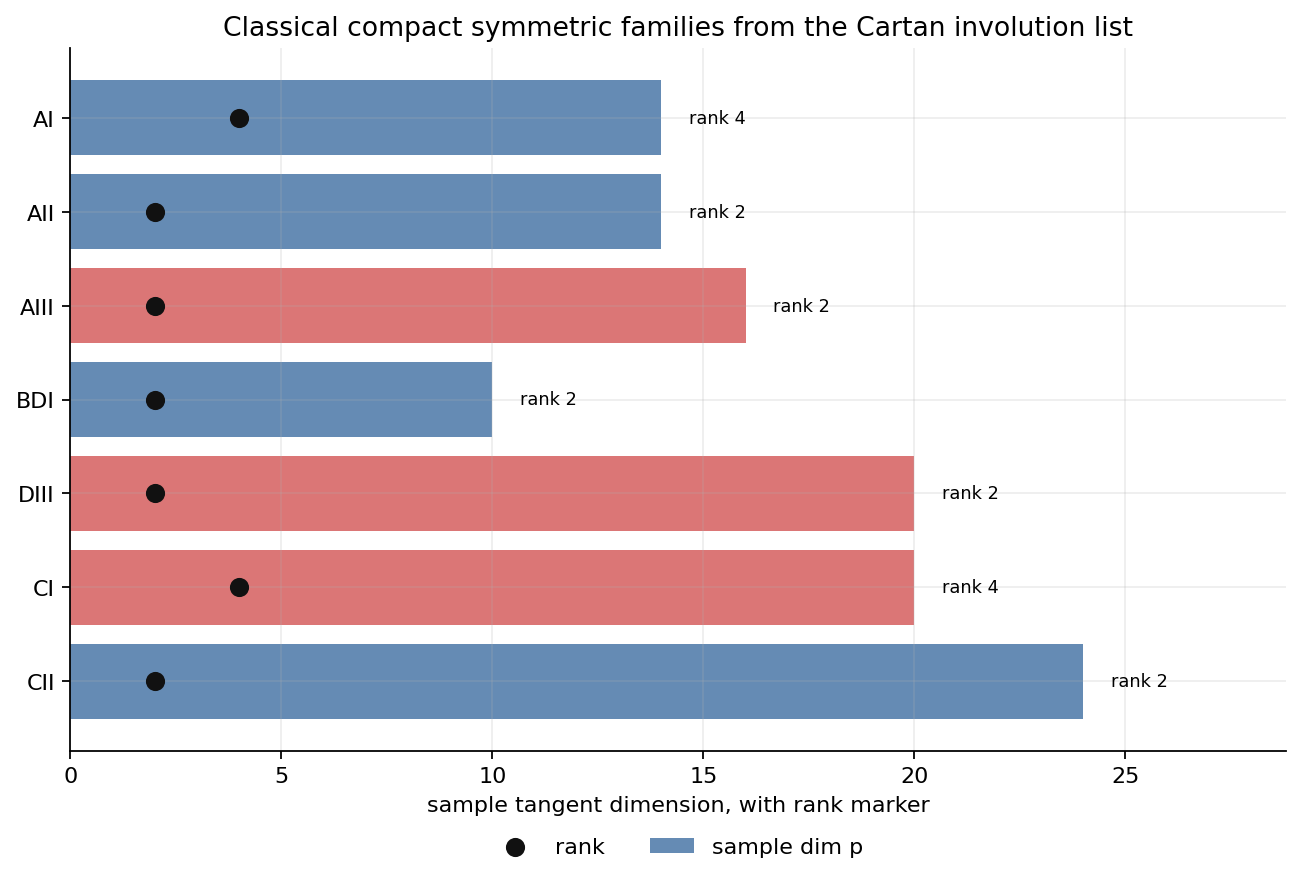

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/figures/classical-cartan-family-rank-ladder.png


[classical-cartan-involution-families.csv](artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/tables/classical-cartan-involution-families.csv)

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/tables/classical-cartan-involution-families.csv


In [4]:
def dim_su(n):
    return n * n - 1


def dim_so(n):
    return n * (n - 1) // 2


def dim_sp(n):
    return n * (2 * n + 1)


def dim_u(n):
    return n * n


families = [
    {
        "type": "AI",
        "parameters": "n=5",
        "compact_u": "su(n)",
        "fixed_k": "so(n)",
        "noncompact_real_form": "sl(n,R)",
        "compact_space": "SU(n)/SO(n)",
        "noncompact_space": "SL(n,R)/SO(n)",
        "rank_formula": "n - 1",
        "sample_rank": 4,
        "sample_u_dim": dim_su(5),
        "sample_k_dim": dim_so(5),
        "hermitian": False,
        "normal_real_form_condition": "yes",
    },
    {
        "type": "AII",
        "parameters": "n=3 in su(2n)",
        "compact_u": "su(2n)",
        "fixed_k": "sp(n)",
        "noncompact_real_form": "su*(2n)",
        "compact_space": "SU(2n)/Sp(n)",
        "noncompact_space": "SU*(2n)/Sp(n)",
        "rank_formula": "n - 1",
        "sample_rank": 2,
        "sample_u_dim": dim_su(6),
        "sample_k_dim": dim_sp(3),
        "hermitian": False,
        "normal_real_form_condition": "no",
    },
    {
        "type": "AIII",
        "parameters": "p=4, q=2",
        "compact_u": "su(p+q)",
        "fixed_k": "s(u(p)+u(q))",
        "noncompact_real_form": "su(p,q)",
        "compact_space": "SU(p+q)/S(U(p)xU(q))",
        "noncompact_space": "SU(p,q)/S(U(p)xU(q))",
        "rank_formula": "q",
        "sample_rank": 2,
        "sample_u_dim": dim_su(6),
        "sample_k_dim": 4 * 4 + 2 * 2 - 1,
        "hermitian": True,
        "normal_real_form_condition": "only special balanced cases through the real-form list",
    },
    {
        "type": "BDI",
        "parameters": "p=5, q=2",
        "compact_u": "so(p+q)",
        "fixed_k": "so(p)+so(q)",
        "noncompact_real_form": "so(p,q)",
        "compact_space": "SO(p+q)/(SO(p)xSO(q))",
        "noncompact_space": "SO0(p,q)/(SO(p)xSO(q))",
        "rank_formula": "q",
        "sample_rank": 2,
        "sample_u_dim": dim_so(7),
        "sample_k_dim": dim_so(5) + dim_so(2),
        "hermitian": False,
        "normal_real_form_condition": "p=q if even total; p=q+1 if odd total",
    },
    {
        "type": "DIII",
        "parameters": "n=5",
        "compact_u": "so(2n)",
        "fixed_k": "u(n)",
        "noncompact_real_form": "so*(2n)",
        "compact_space": "SO(2n)/U(n)",
        "noncompact_space": "SO*(2n)/U(n)",
        "rank_formula": "floor(n/2)",
        "sample_rank": 2,
        "sample_u_dim": dim_so(10),
        "sample_k_dim": dim_u(5),
        "hermitian": True,
        "normal_real_form_condition": "no",
    },
    {
        "type": "CI",
        "parameters": "n=4",
        "compact_u": "sp(n)",
        "fixed_k": "u(n)",
        "noncompact_real_form": "sp(n,R)",
        "compact_space": "Sp(n)/U(n)",
        "noncompact_space": "Sp(n,R)/U(n)",
        "rank_formula": "n",
        "sample_rank": 4,
        "sample_u_dim": dim_sp(4),
        "sample_k_dim": dim_u(4),
        "hermitian": True,
        "normal_real_form_condition": "yes",
    },
    {
        "type": "CII",
        "parameters": "p=3, q=2",
        "compact_u": "sp(p+q)",
        "fixed_k": "sp(p)+sp(q)",
        "noncompact_real_form": "sp(p,q)",
        "compact_space": "Sp(p+q)/(Sp(p)xSp(q))",
        "noncompact_space": "Sp(p,q)/(Sp(p)xSp(q))",
        "rank_formula": "q",
        "sample_rank": 2,
        "sample_u_dim": dim_sp(5),
        "sample_k_dim": dim_sp(3) + dim_sp(2),
        "hermitian": False,
        "normal_real_form_condition": "no",
    },
]

for row in families:
    row["sample_p_dim"] = row["sample_u_dim"] - row["sample_k_dim"]

family_table_path = track(save_csv(families, TABLES / "classical-cartan-involution-families.csv"))

labels = [row["type"] for row in families]
p_dims = np.array([row["sample_p_dim"] for row in families])
ranks = np.array([row["sample_rank"] for row in families])
colors = ["#d65f5f" if row["hermitian"] else "#4c78a8" for row in families]

fig, ax = plt.subplots(figsize=(9.8, 5.7))
y = np.arange(len(families))
ax.barh(y, p_dims, color=colors, alpha=0.86, label="sample dim p")
ax.scatter(ranks, y, color="#111111", s=58, zorder=5, label="rank")
for yi, row in zip(y, families):
    ax.text(row["sample_p_dim"] + 0.65, yi, f"rank {row['sample_rank']}", va="center", fontsize=8)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlim(0, max(p_dims) + 4.8)
ax.set_xlabel("sample tangent dimension, with rank marker")
ax.set_title("Classical compact symmetric families from the Cartan involution list")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
family_plot_path = track(save_matplotlib(fig, FIGURES / "classical-cartan-family-rank-ladder.png"))
plt.close(fig)

dimension_check = {
    "rows": [
        {
            "type": row["type"],
            "sample_u_dim": int(row["sample_u_dim"]),
            "sample_k_dim": int(row["sample_k_dim"]),
            "sample_p_dim": int(row["sample_p_dim"]),
            "sample_rank": int(row["sample_rank"]),
            "rank_not_larger_than_p_dim": bool(row["sample_rank"] <= row["sample_p_dim"]),
            "positive_tangent_dimension": bool(row["sample_p_dim"] > 0),
        }
        for row in families
    ],
}
dimension_check["checks"] = {
    "all_positive_tangent_dimensions": all(row["positive_tangent_dimension"] for row in dimension_check["rows"]),
    "all_ranks_fit_tangent_dimension": all(row["rank_not_larger_than_p_dim"] for row in dimension_check["rows"]),
    "contains_all_seven_classical_families": {row["type"] for row in families} == {"AI", "AII", "AIII", "BDI", "DIII", "CI", "CII"},
}
dimension_json_path = track(save_json(dimension_check, CHECKS / "classical-family-dimension-checks.json"))
CHECK_RESULTS.update({f"classical_{k}": v for k, v in dimension_check["checks"].items()})

show(family_plot_path, width=780)
show(family_table_path)


## 4. A Concrete Cartan Involution Check: Type AIII

For `AIII`, the compact algebra is `su(p+q)` and the involution is conjugation by the signature matrix `I_{p,q}`. Its `+1` eigenspace is block diagonal, and its `-1` eigenspace is off diagonal. The bracket identities below are the local algebraic reason this is a symmetric pair:

`[k, k] subset k`, `[k, p] subset p`, and `[p, p] subset k`.

The example uses `p=2`, `q=1`, so the matrices fit on the page.


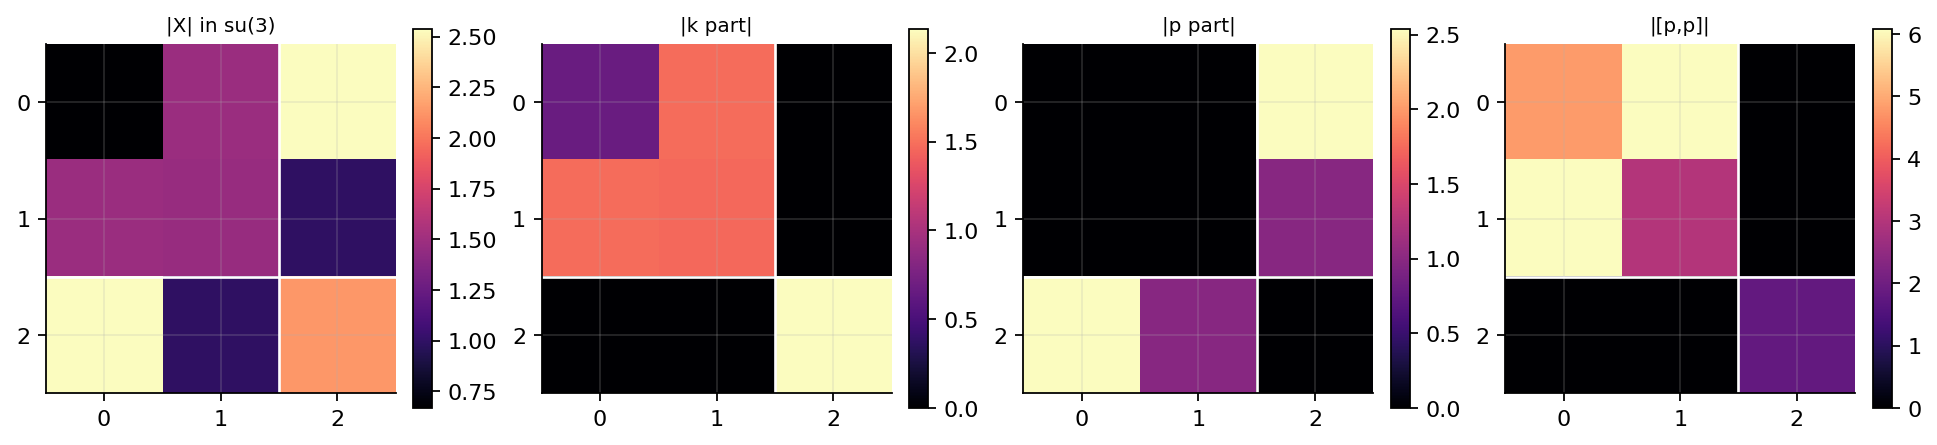

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/figures/aiii-block-cartan-involution.png
{
  "theta_is_involutive": true,
  "decomposition_reconstructs_X": true,
  "k_part_fixed_by_theta": true,
  "p_part_negated_by_theta": true,
  "bracket_kk_lands_in_k": true,
  "bracket_kp_lands_in_p": true,
  "bracket_pp_lands_in_k": true
}


In [5]:
rng = np.random.default_rng(10)
P_AIII = np.diag([1, 1, -1]).astype(complex)


def su3_sample():
    A = rng.normal(size=(3, 3)) + 1j * rng.normal(size=(3, 3))
    X = A - A.conj().T
    X = X - np.trace(X) / 3 * np.eye(3)
    return X


def theta_aiii(X):
    return P_AIII @ X @ P_AIII


def bracket(X, Y):
    return X @ Y - Y @ X


def is_su(X, tol=1e-10):
    return np.linalg.norm(X + X.conj().T) < tol and abs(np.trace(X)) < tol


def is_k(X, tol=1e-10):
    return is_su(X, tol) and np.linalg.norm(theta_aiii(X) - X) < tol


def is_p(X, tol=1e-10):
    return is_su(X, tol) and np.linalg.norm(theta_aiii(X) + X) < tol


X, Y, Z = su3_sample(), su3_sample(), su3_sample()
KX = (X + theta_aiii(X)) / 2
PX = (X - theta_aiii(X)) / 2
KY = (Y + theta_aiii(Y)) / 2
PY = (Y - theta_aiii(Y)) / 2
KZ = (Z + theta_aiii(Z)) / 2
PZ = (Z - theta_aiii(Z)) / 2

aiii_checks = {
    "theta_is_involutive": bool(np.linalg.norm(theta_aiii(theta_aiii(X)) - X) < 1e-10),
    "decomposition_reconstructs_X": bool(np.linalg.norm(KX + PX - X) < 1e-10),
    "k_part_fixed_by_theta": bool(is_k(KX)),
    "p_part_negated_by_theta": bool(is_p(PX)),
    "bracket_kk_lands_in_k": bool(is_k(bracket(KX, KY))),
    "bracket_kp_lands_in_p": bool(is_p(bracket(KX, PY))),
    "bracket_pp_lands_in_k": bool(is_k(bracket(PX, PY))),
}

fig, axes = plt.subplots(1, 4, figsize=(12.0, 3.2), constrained_layout=True)
blocks = [
    ("|X| in su(3)", X),
    ("|k part|", KX),
    ("|p part|", PX),
    ("|[p,p]|", bracket(PX, PY)),
]
for ax, (title, matrix) in zip(axes, blocks):
    image = ax.imshow(np.abs(matrix), cmap="magma")
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.axhline(1.5, color="white", lw=1.2)
    ax.axvline(1.5, color="white", lw=1.2)
    fig.colorbar(image, ax=ax, shrink=0.76)
aiii_path = track(save_matplotlib(fig, FIGURES / "aiii-block-cartan-involution.png"))
plt.close(fig)

aiii_json = {
    "family": "AIII, p=2, q=1",
    "involution": "theta(X) = I_{2,1} X I_{2,1}",
    "checks": aiii_checks,
    "max_numeric_residual": float(max(
        np.linalg.norm(theta_aiii(theta_aiii(X)) - X),
        np.linalg.norm(KX + PX - X),
        np.linalg.norm(theta_aiii(KX) - KX),
        np.linalg.norm(theta_aiii(PX) + PX),
    )),
}
aiii_json_path = track(save_json(aiii_json, CHECKS / "aiii-symmetric-pair-bracket-check.json"))
CHECK_RESULTS.update({f"aiii_{k}": v for k, v in aiii_checks.items()})
show(aiii_path, width=820)
print(json.dumps(aiii_json["checks"], indent=2))


## 5. Root Systems, Reflections, and Weyl Chambers

The source span then switches from matrix groups to abstract root systems. A root system is a finite set of nonzero vectors closed under its own reflections, with integral Cartan entries. This is the combinatorial object that later supports Dynkin diagrams.

For `A2`, the six roots form a hexagon. The shaded sector is one Weyl chamber for the simple roots `alpha1` and `alpha2`; crossing a wall changes the positive-root convention. The static PNG is durable for notes, and the HTML artifact gives a hoverable version.


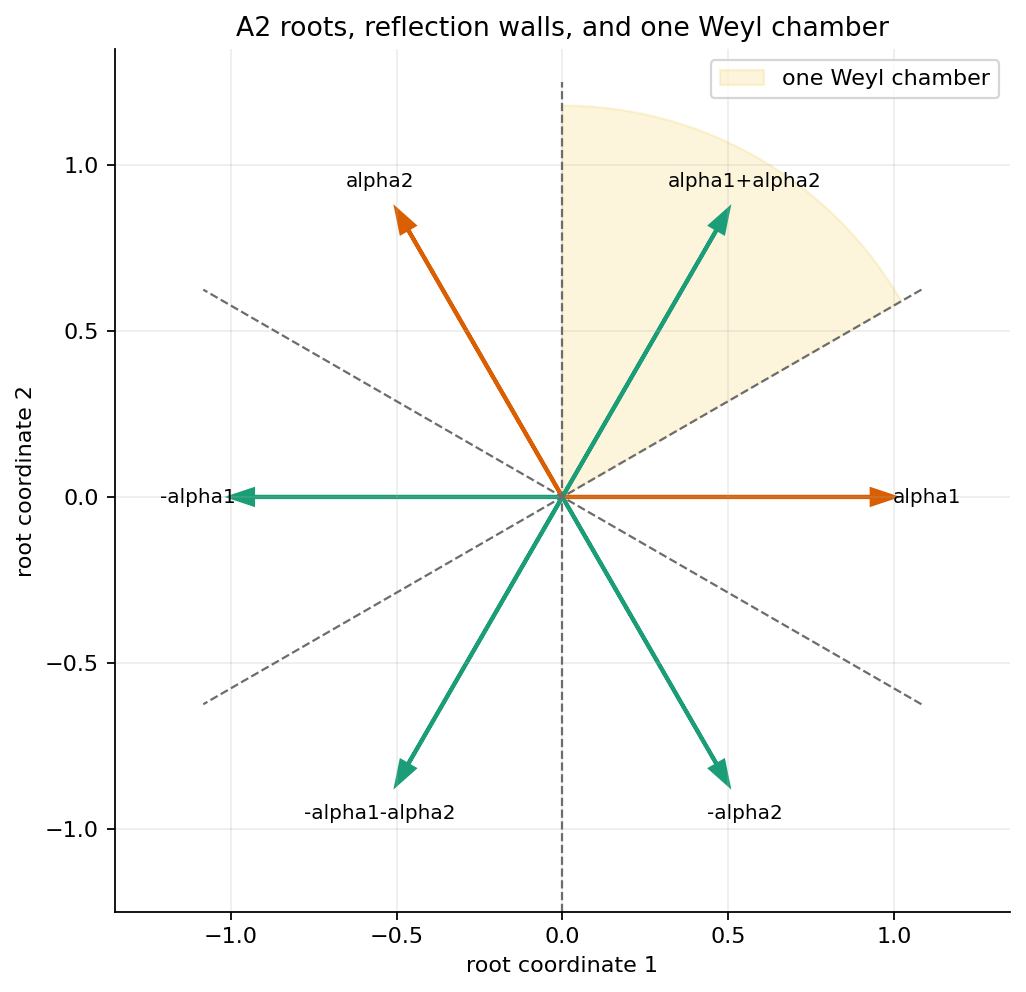

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/figures/root-system-a2-weyl-chambers.png


artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/html/root-system-a2-weyl-chambers.html
A2 simple Cartan matrix:
[[ 2 -1]
 [-1  2]]


In [6]:
sqrt3 = math.sqrt(3)
alpha1 = np.array([1.0, 0.0])
alpha2 = np.array([-0.5, sqrt3 / 2])
A2_roots = [
    alpha1,
    alpha2,
    alpha1 + alpha2,
    -alpha1,
    -alpha2,
    -(alpha1 + alpha2),
]
A2_labels = ["alpha1", "alpha2", "alpha1+alpha2", "-alpha1", "-alpha2", "-alpha1-alpha2"]


def reflect(beta, alpha):
    return beta - 2 * np.dot(beta, alpha) / np.dot(alpha, alpha) * alpha


def close_member(vector, roots, tol=1e-9):
    return any(np.linalg.norm(vector - root) < tol for root in roots)


def cartan_float(beta, alpha):
    return int(round(2 * np.dot(beta, alpha) / np.dot(alpha, alpha)))


A2_reflection_invariant = all(close_member(reflect(beta, alpha), A2_roots) for alpha in A2_roots for beta in A2_roots)
A2_cartan_entries = sorted({cartan_float(beta, alpha) for alpha in A2_roots for beta in A2_roots})
A2_cartan_integral = all(abs(2 * np.dot(beta, alpha) / np.dot(alpha, alpha) - cartan_float(beta, alpha)) < 1e-9 for alpha in A2_roots for beta in A2_roots)
A2_simple_cartan = np.array([
    [cartan_float(alpha1, alpha1), cartan_float(alpha1, alpha2)],
    [cartan_float(alpha2, alpha1), cartan_float(alpha2, alpha2)],
])

fig, ax = plt.subplots(figsize=(7.4, 7.0))
ax.add_patch(Wedge((0, 0), 1.18, 30, 90, color="#f2cf5b", alpha=0.22, label="one Weyl chamber"))
for root, label in zip(A2_roots, A2_labels):
    color = "#d95f02" if label in {"alpha1", "alpha2"} else "#1b9e77"
    ax.arrow(0, 0, root[0], root[1], head_width=0.045, length_includes_head=True, color=color, linewidth=1.8)
    ax.text(1.1 * root[0], 1.1 * root[1], label, ha="center", va="center", fontsize=9)

for root in [alpha1, alpha2, alpha1 + alpha2]:
    direction = np.array([-root[1], root[0]])
    direction = direction / np.linalg.norm(direction)
    ax.plot([-1.25 * direction[0], 1.25 * direction[0]], [-1.25 * direction[1], 1.25 * direction[1]], color="#6c6c6c", lw=1.0, ls="--")

ax.set_aspect("equal")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.25, 1.35)
ax.set_title("A2 roots, reflection walls, and one Weyl chamber")
ax.set_xlabel("root coordinate 1")
ax.set_ylabel("root coordinate 2")
ax.legend(loc="upper right")
a2_png_path = track(save_matplotlib(fig, FIGURES / "root-system-a2-weyl-chambers.png"))
plt.close(fig)

if go is not None:
    fig_html = go.Figure()
    for root, label in zip(A2_roots, A2_labels):
        fig_html.add_trace(go.Scatter(
            x=[0, root[0]],
            y=[0, root[1]],
            mode="lines+markers+text",
            text=["", label],
            textposition="top center",
            name=label,
        ))
    for idx, root in enumerate([alpha1, alpha2, alpha1 + alpha2], start=1):
        direction = np.array([-root[1], root[0]])
        direction = direction / np.linalg.norm(direction)
        fig_html.add_trace(go.Scatter(
            x=[-1.3 * direction[0], 1.3 * direction[0]],
            y=[-1.3 * direction[1], 1.3 * direction[1]],
            mode="lines",
            line={"dash": "dash", "color": "gray"},
            name=f"wall {idx}",
        ))
    fig_html.update_layout(
        title="A2 root system and reflection hyperplanes",
        xaxis={"scaleanchor": "y", "title": "x"},
        yaxis={"title": "y"},
        width=760,
        height=640,
    )
    a2_html_path = track(save_plotly_html(fig_html, HTML / "root-system-a2-weyl-chambers.html"))
else:
    a2_html_path = None

CHECK_RESULTS["a2_reflection_invariance"] = bool(A2_reflection_invariant)
CHECK_RESULTS["a2_cartan_entries_integral"] = bool(A2_cartan_integral)
show(a2_png_path, width=650)
if a2_html_path is not None:
    show(a2_html_path, width=760, height=560)
print("A2 simple Cartan matrix:")
print(A2_simple_cartan)


## 6. Reduced, Nonreduced, and Root-String Checks

The printed span emphasizes a subtle point: ordinary complex roots are reduced, while restricted roots need not be. The rank-two system `BC2` is the smallest useful picture of that behavior because it contains both `alpha` and `2 alpha`.

The right panel checks Corollary 3.5 visually. For the `B2` roots, take `alpha = e1` and `beta = e2 - e1`. The roots of the form `beta + n alpha` occur with no gaps for `n = 0, 1, 2`, and `p - q = -2` matches the Cartan integer.


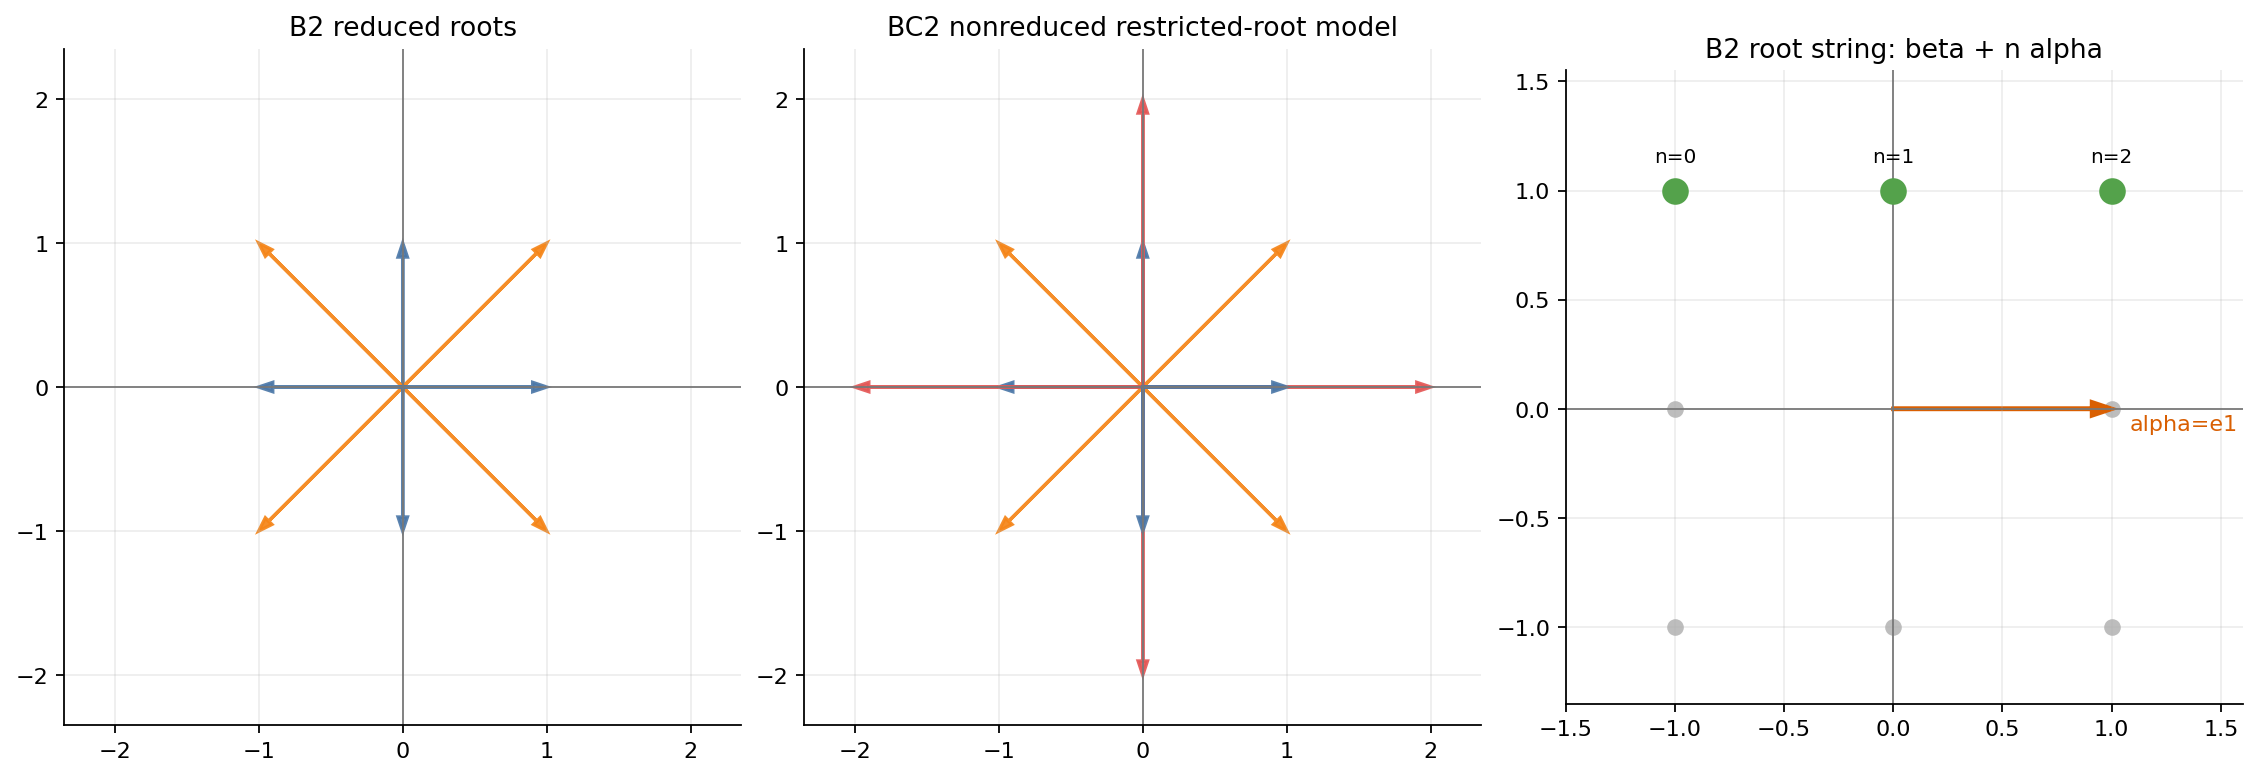

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/figures/nonreduced-bc2-root-string.png
{
  "A2_is_a_root_system_model": true,
  "B2_root_string_has_no_gap_and_matches_cartan": true,
  "BC2_is_nonreduced": true,
  "BC2_reduced_subsystems_match_lemma_3_2": true
}


In [7]:
def tup_add(a, b):
    return tuple(x + y for x, y in zip(a, b))


def tup_mul(c, a):
    return tuple(c * x for x in a)


def tup_dot(a, b):
    return sum(x * y for x, y in zip(a, b))


def as_fraction_tuple(a):
    return tuple(Fraction(x) for x in a)


def reflect_tuple(beta, alpha):
    beta = as_fraction_tuple(beta)
    alpha = as_fraction_tuple(alpha)
    factor = Fraction(2 * tup_dot(beta, alpha), tup_dot(alpha, alpha))
    return tuple(beta[i] - factor * alpha[i] for i in range(len(alpha)))


def reflection_invariant(rootset):
    roots = {as_fraction_tuple(root) for root in rootset}
    return all(reflect_tuple(beta, alpha) in roots for alpha in roots for beta in roots)


def is_reduced(rootset):
    roots = {as_fraction_tuple(root) for root in rootset}
    return not any(tup_mul(Fraction(2), root) in roots for root in roots)


e1 = (1, 0)
e2 = (0, 1)
B2_roots = {
    (1, 0), (-1, 0), (0, 1), (0, -1),
    (1, 1), (1, -1), (-1, 1), (-1, -1),
}
BC2_roots = set(B2_roots) | {(2, 0), (-2, 0), (0, 2), (0, -2)}
BC2_fraction_roots = {as_fraction_tuple(root) for root in BC2_roots}
R_indivisible = {root for root in BC2_fraction_roots if tup_mul(Fraction(1, 2), root) not in BC2_fraction_roots}
R_unmultipliable = {root for root in BC2_fraction_roots if tup_mul(Fraction(2), root) not in BC2_fraction_roots}

alpha = (1, 0)
beta = (-1, 1)
string_members = []
for n in range(-4, 5):
    candidate = tup_add(beta, tup_mul(n, alpha))
    if candidate in B2_roots:
        string_members.append(n)
p_string, q_string = min(string_members), max(string_members)
cartan_beta_alpha = Fraction(2 * tup_dot(beta, alpha), tup_dot(alpha, alpha))
root_string_ok = string_members == list(range(p_string, q_string + 1)) and Fraction(p_string - q_string) == cartan_beta_alpha

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.8), constrained_layout=True)

for ax, roots, title in [
    (axes[0], B2_roots, "B2 reduced roots"),
    (axes[1], BC2_roots, "BC2 nonreduced restricted-root model"),
]:
    for root in roots:
        length = tup_dot(root, root)
        color = "#4c78a8" if length == 1 else ("#f58518" if length == 2 else "#e45756")
        ax.arrow(0, 0, root[0], root[1], head_width=0.065, length_includes_head=True, color=color, linewidth=1.5, alpha=0.92)
    ax.set_aspect("equal")
    ax.set_xlim(-2.35, 2.35)
    ax.set_ylim(-2.35, 2.35)
    ax.axhline(0, color="#777777", lw=0.8)
    ax.axvline(0, color="#777777", lw=0.8)
    ax.set_title(title)

axes[2].set_title("B2 root string: beta + n alpha")
for root in B2_roots:
    axes[2].scatter(root[0], root[1], s=42, color="#bdbdbd")
for n in string_members:
    point = tup_add(beta, tup_mul(n, alpha))
    axes[2].scatter(point[0], point[1], s=120, color="#54a24b", zorder=4)
    axes[2].text(point[0], point[1] + 0.13, f"n={n}", ha="center", fontsize=9)
axes[2].arrow(0, 0, alpha[0], alpha[1], head_width=0.06, length_includes_head=True, color="#d95f02", linewidth=2.0)
axes[2].text(alpha[0] + 0.08, alpha[1] - 0.1, "alpha=e1", color="#d95f02")
axes[2].set_aspect("equal")
axes[2].set_xlim(-1.5, 1.6)
axes[2].set_ylim(-1.35, 1.55)
axes[2].axhline(0, color="#777777", lw=0.8)
axes[2].axvline(0, color="#777777", lw=0.8)

bc2_path = track(save_matplotlib(fig, FIGURES / "nonreduced-bc2-root-string.png"))
plt.close(fig)

root_checks = {
    "A2": {
        "reflection_invariant": bool(A2_reflection_invariant),
        "cartan_entries": [int(x) for x in A2_cartan_entries],
        "cartan_entries_integral": bool(A2_cartan_integral),
        "simple_cartan_matrix": A2_simple_cartan.tolist(),
    },
    "B2": {
        "reflection_invariant": bool(reflection_invariant(B2_roots)),
        "is_reduced": bool(is_reduced(B2_roots)),
        "root_string_alpha": alpha,
        "root_string_beta": beta,
        "string_n_values": string_members,
        "cartan_beta_alpha": str(cartan_beta_alpha),
        "p_minus_q": p_string - q_string,
        "root_string_check": bool(root_string_ok),
    },
    "BC2": {
        "reflection_invariant": bool(reflection_invariant(BC2_roots)),
        "is_reduced": bool(is_reduced(BC2_roots)),
        "indivisible_subsystem_size": len(R_indivisible),
        "unmultipliable_subsystem_size": len(R_unmultipliable),
        "indivisible_subsystem_reduced": bool(is_reduced(R_indivisible)),
        "unmultipliable_subsystem_reduced": bool(is_reduced(R_unmultipliable)),
    },
}
root_checks["checks"] = {
    "A2_is_a_root_system_model": root_checks["A2"]["reflection_invariant"] and root_checks["A2"]["cartan_entries_integral"],
    "B2_root_string_has_no_gap_and_matches_cartan": bool(root_string_ok),
    "BC2_is_nonreduced": not root_checks["BC2"]["is_reduced"],
    "BC2_reduced_subsystems_match_lemma_3_2": root_checks["BC2"]["indivisible_subsystem_reduced"] and root_checks["BC2"]["unmultipliable_subsystem_reduced"],
}
root_json_path = track(save_json(root_checks, CHECKS / "root-system-invariants.json"))
CHECK_RESULTS.update({f"root_{k}": v for k, v in root_checks["checks"].items()})
show(bc2_path, width=900)
print(json.dumps(root_checks["checks"], indent=2))


## 7. Dynkin Diagrams as Cartan-Integer Compression

The source span has only just reached bases and Weyl chambers, but the chapter introduction tells us where this machinery is going: classification by Dynkin diagrams. The diagram is not a separate object from the root system. It records the off-diagonal Cartan integers of a simple basis.

For rank two, the number of edges is controlled by the product of the two off-diagonal entries. The direction points toward the shorter root when the roots have different lengths.


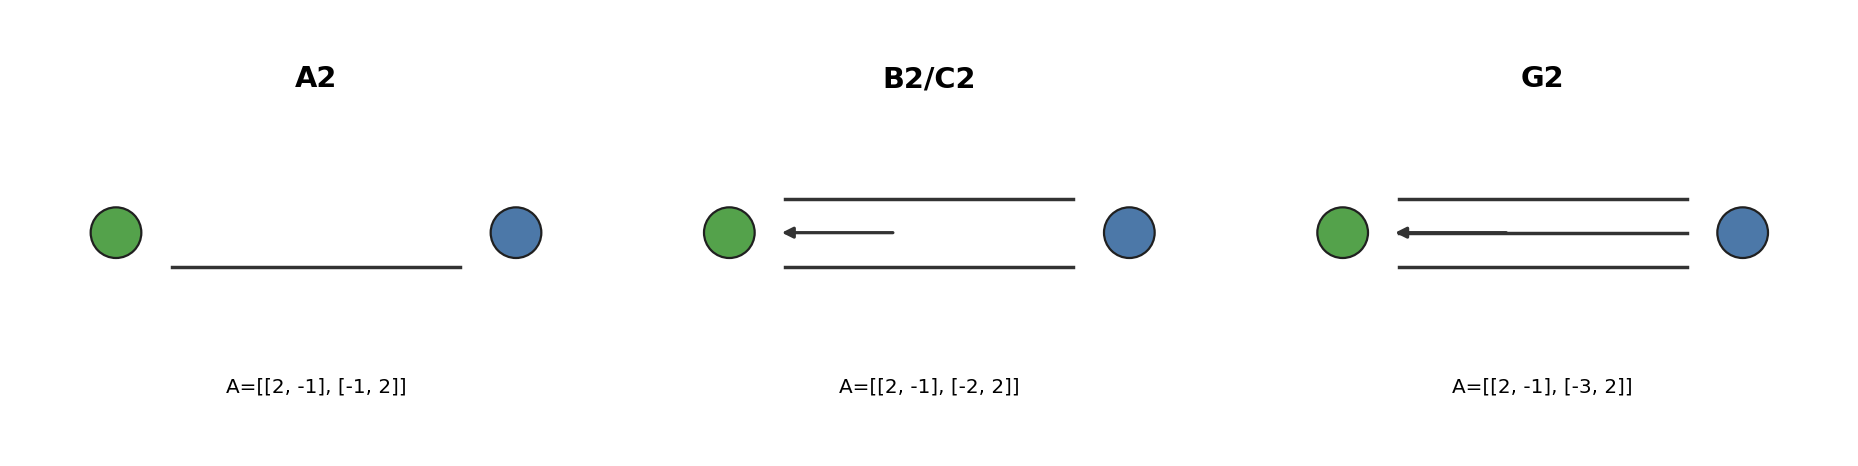

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/figures/dynkin-cartan-encoding.png


In [8]:
dynkin_cases = {
    "A2": {"cartan": np.array([[2, -1], [-1, 2]]), "symmetrizer": [1, 1]},
    "B2/C2": {"cartan": np.array([[2, -1], [-2, 2]]), "symmetrizer": [2, 1]},
    "G2": {"cartan": np.array([[2, -1], [-3, 2]]), "symmetrizer": [3, 1]},
}


def cartan_matrix_valid(A, d):
    A = np.array(A)
    d = np.array(d)
    diagonal_ok = np.all(np.diag(A) == 2)
    offdiag_ok = all(A[i, j] <= 0 and float(A[i, j]).is_integer() for i in range(A.shape[0]) for j in range(A.shape[1]) if i != j)
    zero_symmetry_ok = all((A[i, j] == 0) == (A[j, i] == 0) for i in range(A.shape[0]) for j in range(A.shape[1]))
    symmetrized = np.diag(d) @ A
    symmetrizable_ok = np.allclose(symmetrized, symmetrized.T)
    return bool(diagonal_ok and offdiag_ok and zero_symmetry_ok and symmetrizable_ok)


fig, axes = plt.subplots(1, 3, figsize=(11.5, 2.8), constrained_layout=True)
dynkin_checks = {}
for ax, (name, data) in zip(axes, dynkin_cases.items()):
    A = data["cartan"]
    d = data["symmetrizer"]
    multiplicity = max(abs(int(A[0, 1])), abs(int(A[1, 0])))
    dynkin_checks[name] = {
        "cartan_matrix": A.tolist(),
        "symmetrizer": d,
        "valid_generalized_cartan_matrix": cartan_matrix_valid(A, d),
        "edge_multiplicity": int(multiplicity),
    }
    ax.scatter([0, 1], [0, 0], s=520, color=["#54a24b", "#4c78a8"], edgecolor="#202020", zorder=5)
    ax.text(0, 0, "1", ha="center", va="center", color="white", weight="bold")
    ax.text(1, 0, "2", ha="center", va="center", color="white", weight="bold")
    offsets = np.linspace(-0.075, 0.075, multiplicity)
    for offset in offsets:
        ax.plot([0.14, 0.86], [offset, offset], color="#333333", lw=1.55)
    if multiplicity > 1:
        ax.annotate("", xy=(0.12, 0), xytext=(0.42, 0), arrowprops={"arrowstyle": "-|>", "lw": 1.45, "color": "#333333"})
    ax.text(0.5, 0.34, name, ha="center", va="center", fontsize=13, weight="bold")
    ax.text(0.5, -0.34, f"A={A.tolist()}", ha="center", va="center", fontsize=9)
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylim(-0.48, 0.48)
    ax.set_axis_off()

dynkin_path = track(save_matplotlib(fig, FIGURES / "dynkin-cartan-encoding.png"))
plt.close(fig)
dynkin_json = {
    "note": "Rank-two Dynkin diagrams encode the off-diagonal Cartan integers of a simple basis.",
    "cases": dynkin_checks,
    "checks": {
        "all_rank_two_cartan_matrices_valid": all(item["valid_generalized_cartan_matrix"] for item in dynkin_checks.values()),
        "edge_multiplicities_are_1_2_3": sorted(item["edge_multiplicity"] for item in dynkin_checks.values()) == [1, 2, 3],
    },
}
dynkin_json_path = track(save_json(dynkin_json, CHECKS / "dynkin-cartan-checks.json"))
CHECK_RESULTS.update({f"dynkin_{k}": v for k, v in dynkin_json["checks"].items()})
show(dynkin_path, width=820)


## 8. Applied Lab: Change the Parameters, Watch the Rank

This lab is intentionally small. Change `lab_q` or the offset between `p` and `q`, then rerun the cell. The checks should still confirm that the tangent dimension is positive and that rank stays at the size of the maximal abelian block described in the source span.

The three rows compare the same `p, q` values across `AIII`, `BDI`, and `CII`. The rank agrees, but the tangent dimensions differ because the underlying scalar field changes from complex to real to quaternionic behavior.


In [9]:
def family_sample(family, p, q):
    if family == "AIII":
        return {"family": family, "p": p, "q": q, "rank": q, "p_dimension": 2 * p * q}
    if family == "BDI":
        return {"family": family, "p": p, "q": q, "rank": q, "p_dimension": p * q}
    if family == "CII":
        return {"family": family, "p": p, "q": q, "rank": q, "p_dimension": 4 * p * q}
    raise ValueError(f"unknown family {family}")


lab_rows = []
for lab_q in [1, 2, 3]:
    lab_p = lab_q + 2
    for family in ["BDI", "AIII", "CII"]:
        lab_rows.append(family_sample(family, lab_p, lab_q))

lab_table_path = track(save_csv(lab_rows, TABLES / "lab-classical-rank-sweep.csv"))
lab_checks = {
    "rows": lab_rows,
    "checks": {
        "all_dimensions_positive": all(row["p_dimension"] > 0 for row in lab_rows),
        "rank_equals_q_for_these_three_families": all(row["rank"] == row["q"] for row in lab_rows),
        "dimension_order_real_complex_quaternionic": all(
            family_sample("BDI", q + 2, q)["p_dimension"]
            < family_sample("AIII", q + 2, q)["p_dimension"]
            < family_sample("CII", q + 2, q)["p_dimension"]
            for q in [1, 2, 3]
        ),
    },
}
lab_json_path = track(save_json(lab_checks, CHECKS / "lab-parameter-sweep.json"))
CHECK_RESULTS.update({f"lab_{k}": v for k, v in lab_checks["checks"].items()})
show(lab_table_path)
for row in lab_rows:
    print(f"{row['family']:>4} p={row['p']} q={row['q']} rank={row['rank']} dim(p)={row['p_dimension']}")


[lab-classical-rank-sweep.csv](artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/tables/lab-classical-rank-sweep.csv)

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/tables/lab-classical-rank-sweep.csv
 BDI p=3 q=1 rank=1 dim(p)=3
AIII p=3 q=1 rank=1 dim(p)=6
 CII p=3 q=1 rank=1 dim(p)=12
 BDI p=4 q=2 rank=2 dim(p)=8
AIII p=4 q=2 rank=2 dim(p)=16
 CII p=4 q=2 rank=2 dim(p)=32
 BDI p=5 q=3 rank=3 dim(p)=15
AIII p=5 q=3 rank=3 dim(p)=30
 CII p=5 q=3 rank=3 dim(p)=60


## 9. Final Sanity Checks

The final cell records artifact sizes and check results in `checks/final_sanity.json`. It deliberately checks mathematical invariants, not just file existence.


In [10]:
all_checks_passed = all(bool(value) for value in CHECK_RESULTS.values())
final_sanity = {
    "unit_key": UNIT_KEY,
    "title": UNIT_TITLE,
    "source_span": "printed pages 438-458, approximately PDF pages 465-485",
    "artifact_count_before_final_json": len(GENERATED_ARTIFACTS),
    "artifacts": [
        {"path": rel(path), "bytes": int(Path(path).stat().st_size)}
        for path in GENERATED_ARTIFACTS
    ],
    "checks": {key: bool(value) for key, value in sorted(CHECK_RESULTS.items())},
    "all_checks_passed": bool(all_checks_passed),
}
final_sanity_path = track(save_json(final_sanity, CHECKS / "final_sanity.json"))
assert_artifacts(GENERATED_ARTIFACTS, min_bytes=80)
assert final_sanity["all_checks_passed"], "One or more Chapter 10 invariant checks failed"
show(final_sanity_path)
print(f"final_sanity passed with {len(GENERATED_ARTIFACTS)} tracked artifacts")


`final_sanity.json`

artifacts/chapter-10-classification-of-simple-lie-algebras-and-symmetric/checks/final_sanity.json
final_sanity passed with 18 tracked artifacts


## Takeaways

- The source span starts classification by changing the object of study: isometry classes of irreducible symmetric spaces are handled through orthogonal symmetric Lie algebras.
- Type II is the group case: a diagonal quotient model explains why compact simple groups with bi-invariant metrics appear.
- Type I is the real-form and involution case: compact simple algebras, conjugacy classes of involutions, and centers supply the global classification data.
- The classical families `AI`, `AII`, `AIII`, `BDI`, `DIII`, `CI`, and `CII` are best read as fixed-algebra plus tangent-block data, with rank coming from a maximal abelian subspace in the `p` part.
- Root systems are the finite reflection systems behind the later Dynkin-diagram classification. Reflection invariance, integral Cartan entries, root strings, and reduced/nonreduced behavior are all checkable in rank two.
